In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np

df = pd.read_csv(
    '/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/hashfrag/gosai/k562_gosai_filtered.csv.gz', compression='gzip'
)

# parse ref_minus_alt from list-string to float
df['ref_minus_alt_val'] = df['ref_minus_alt'].apply(lambda x: ast.literal_eval(x)[0] if isinstance(x, str) else float(x))

# pivot: rows = variant_id, cols = offset
pivot = df.pivot(index='variant_id', columns='offset', values='ref_minus_alt_val')
pivot.columns = [f'offset_{c}' for c in pivot.columns]
pivot.shape

(1302, 11)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


def describe_offset_label(val):
    try:
        offset = int(val.replace("offset_", ""))
    except ValueError:
        return val
    return str(-offset)

def create_heatmap(df, title, output_file):
    plt.figure(figsize=(12, 10), dpi=300)
    sns.set(style='white', font_scale=2)
    pearson_corr = df.corr("pearson")
    r_squared_matrix = pearson_corr**2
    mask = np.triu(np.ones_like(r_squared_matrix, dtype=bool))
    # Remove rows and columns that are fully masked
    unmasked_rows = ~np.all(mask, axis=1)
    unmasked_cols = ~np.all(mask, axis=0)
    trimmed_matrix = r_squared_matrix.loc[unmasked_rows, unmasked_cols]
    trimmed_mask = mask[unmasked_rows, :][:, unmasked_cols]

    print(trimmed_matrix.index)
    print(trimmed_matrix.columns)
    
    trimmed_matrix.index = [describe_offset_label(v) for v in trimmed_matrix.index]
    trimmed_matrix.columns = [describe_offset_label(v) for v in trimmed_matrix.columns]

    colors = ['#ffffff', '#3361A5']

    cmap = LinearSegmentedColormap.from_list("custom", colors, N=100)
    
    ax = sns.heatmap(
        trimmed_matrix, 
        annot=True, 
        mask=trimmed_mask, 
        cmap=cmap, 
        vmin=0, 
        vmax=1,
        square=True, 
        linewidths=0.5, 
        annot_kws={"size": 20, "weight": "bold"},
        fmt='.2f'  
    )
    
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_file, format='svg')
    plt.close()


In [3]:
# order columns so that, after the -offset relabeling in create_heatmap,
# labels read left-to-right / top-to-bottom as upstream (negative) -> downstream (positive)
offset_cols_sorted = sorted(pivot.columns, key=lambda c: int(c.replace('offset_', '')), reverse=True)
pivot_sorted = pivot[offset_cols_sorted]

create_heatmap(
    pivot_sorted,
    title='r² of ref_minus_alt across positions (K562 Gosai)',
    output_file='/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/hashfrag/k562_gosai_position_corr_heatmap.svg',
)


Index(['offset_80', 'offset_60', 'offset_40', 'offset_20', 'offset_0',
       'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80', 'offset_-90'],
      dtype='object')
Index(['offset_90', 'offset_80', 'offset_60', 'offset_40', 'offset_20',
       'offset_0', 'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80'],
      dtype='object')


In [4]:
# scale each variant's row by its most extreme (max abs) offset so effects are comparable across variants
offset_cols_sorted = sorted(pivot.columns, key=lambda c: int(c.replace('offset_', '')), reverse=True)
scaled = pivot[offset_cols_sorted].apply(lambda row: row / row.loc[row.abs().idxmax()], axis=1)

# relabel columns as position (= -offset) so axis reads upstream (negative) -> downstream (positive)
positions = [-int(c.replace('offset_', '')) for c in offset_cols_sorted]
scaled.columns = positions
scaled.head()

,-90,-80,-60,-40,-20,0,20,40,60,80,90
variant_id,,,,,,,,,,,
chr10_100267650_C_T,1.000000,0.708663,0.724750,0.836937,0.633669,0.656693,0.663021,0.576097,0.709309,0.276210,0.101949
chr10_101845957_T_C,0.073374,0.065198,0.014267,-0.009873,-0.001452,-0.029878,-0.040146,-0.037085,-0.011540,0.038717,1.000000
chr10_102006554_G_A,0.656169,0.623101,0.399716,0.496116,0.644989,0.873596,0.997187,1.000000,0.878666,0.940082,0.363517
chr10_103076162_C_T,0.309625,0.995166,0.885399,0.625089,0.263388,0.764704,0.841389,0.920871,1.000000,0.892122,0.753848
chr10_103587395_G_A,-0.034781,0.064153,0.798185,1.000000,0.834870,0.774764,0.513404,-0.575443,0.287704,0.019724,0.509072


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky_3/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


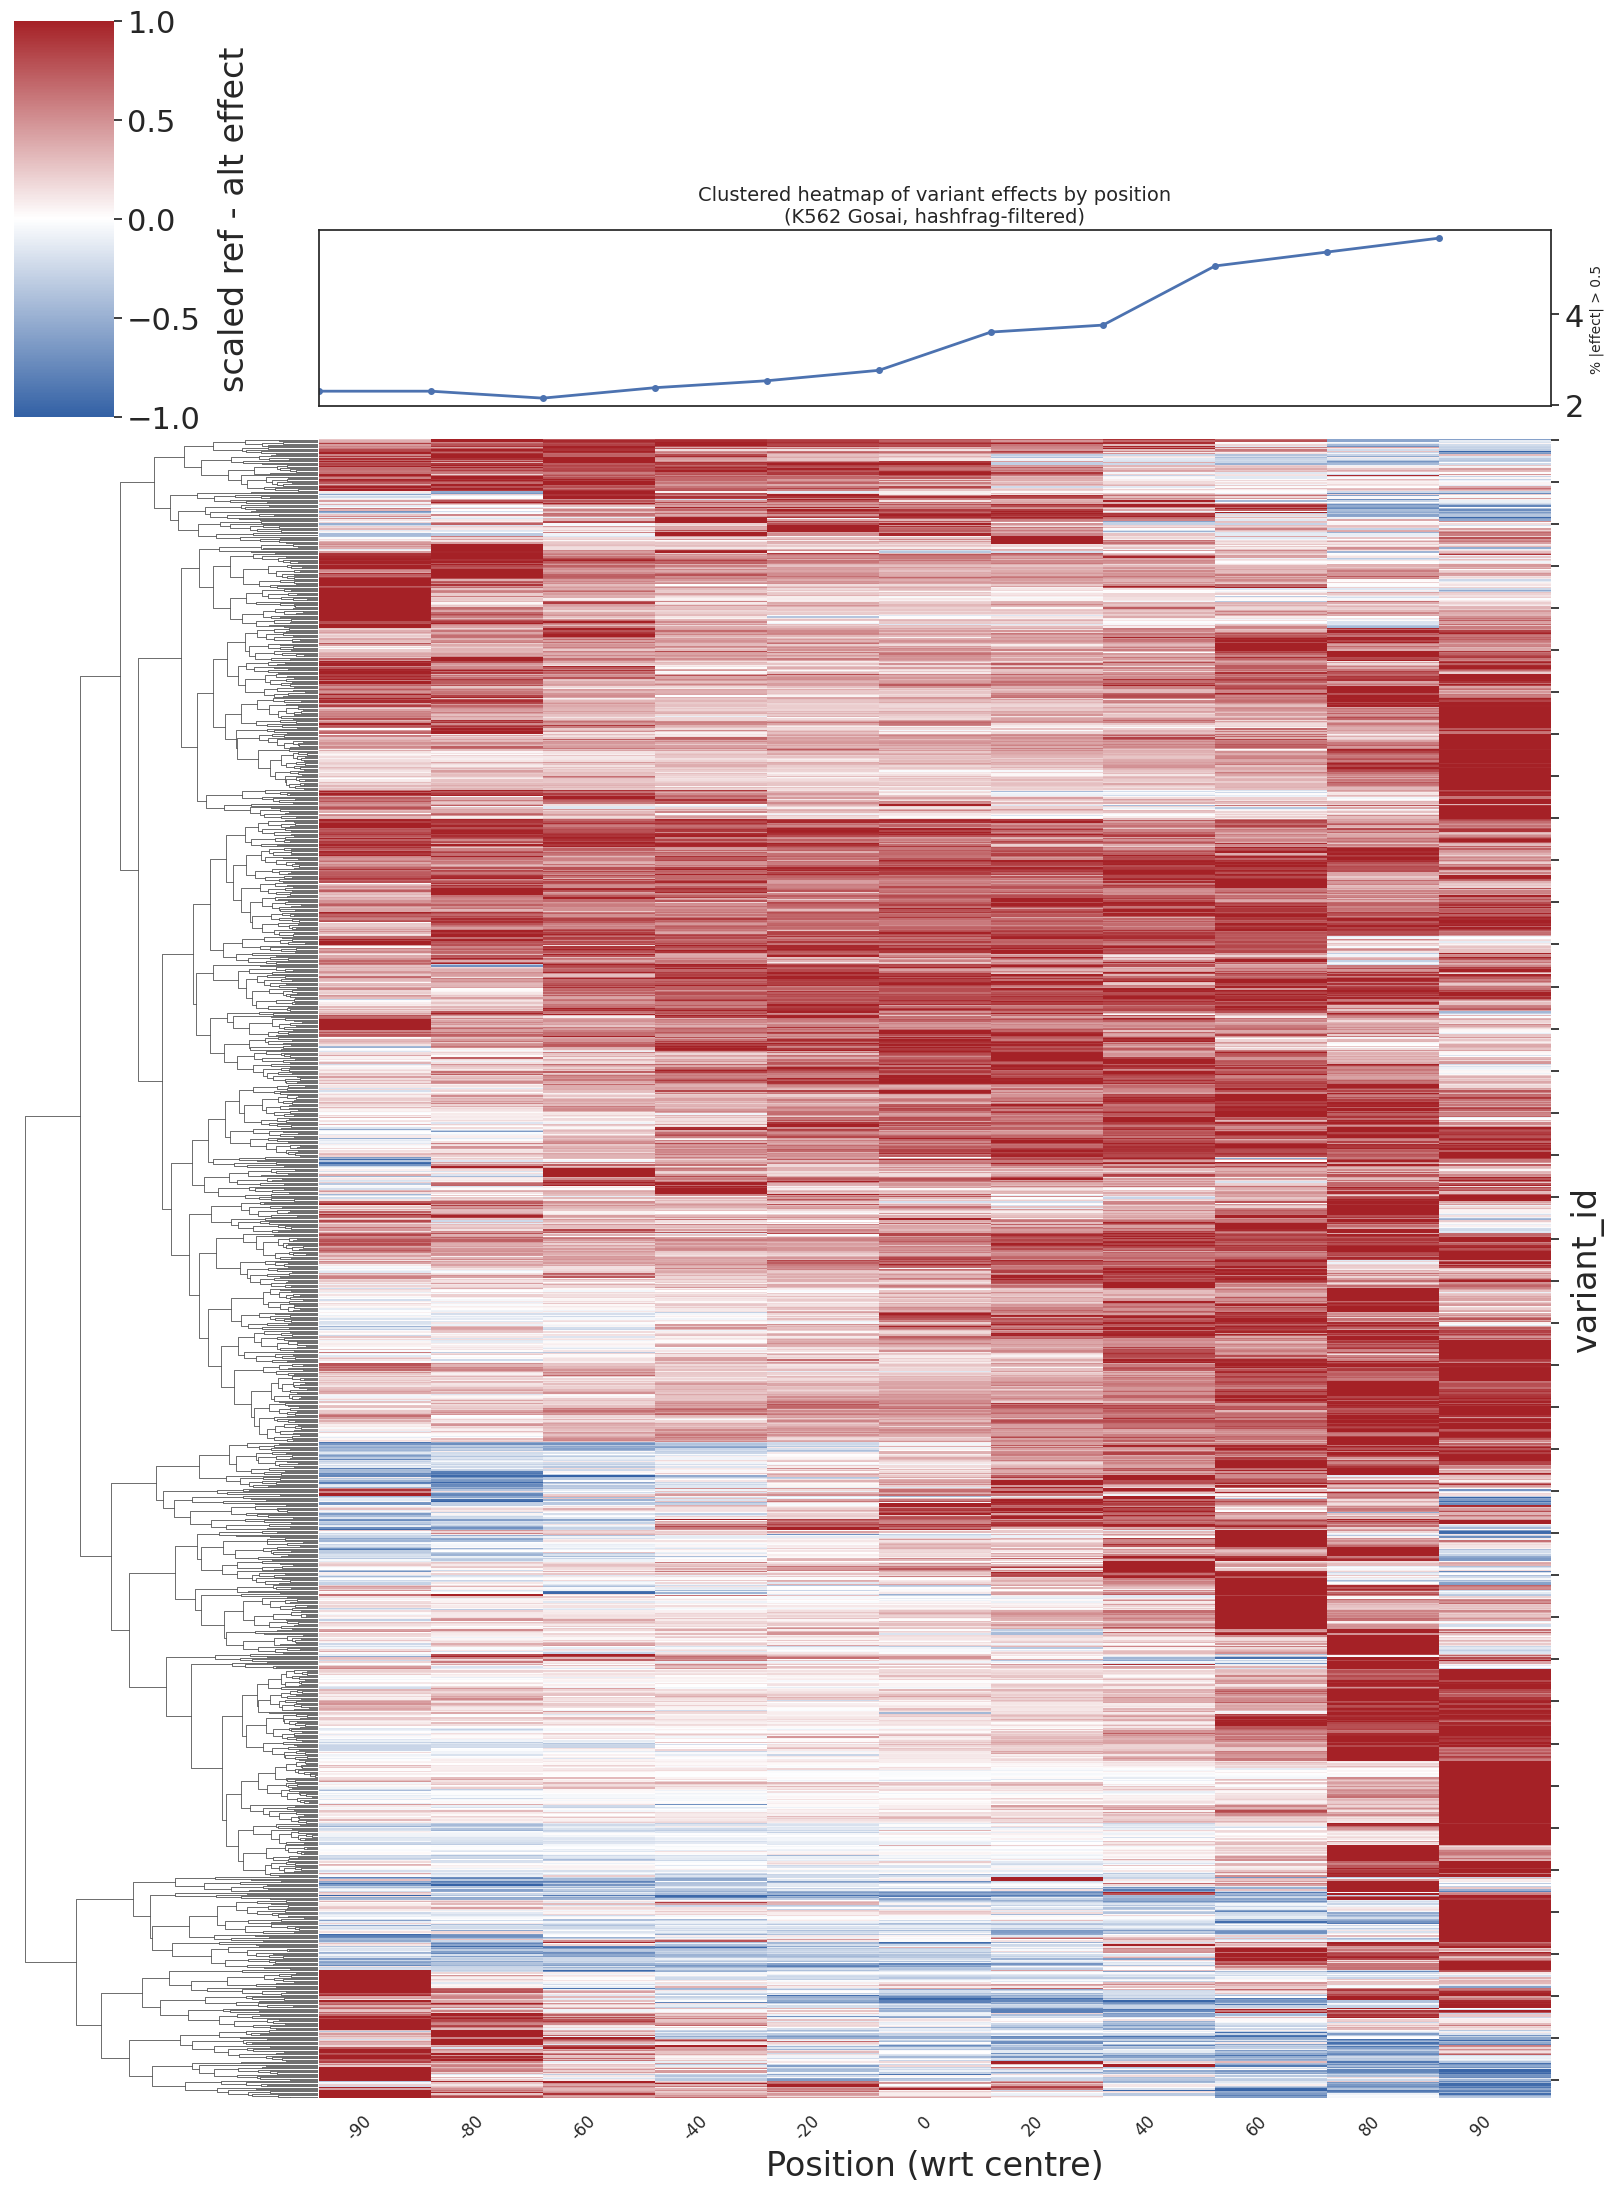

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = ['#3361A5', '#ffffff', '#A52126']
cmap = LinearSegmentedColormap.from_list('custom_red_white_blue', colors, N=256)

g = sns.clustermap(
    scaled,
    cmap=cmap,
    metric='euclidean',
    method='complete',
    figsize=(20, 22),
    annot=False,
    col_cluster=False,
    z_score=None,
    standard_scale=None,
    vmin=-1,
    vmax=1,
)

g.ax_heatmap.set_xticks([i + 0.5 for i in range(len(positions))])
g.ax_heatmap.set_xticklabels(positions, rotation=45, ha='right', fontsize=12)
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_xlabel('Position (wrt centre)')
g.ax_heatmap.set_ylabel('variant_id')
g.cax.set_ylabel('scaled ref - alt effect', rotation=90, labelpad=12)

# % of variants with |ref - alt| > 0.5 at each position (raw, unscaled effect),
# plotted above the heatmap and aligned to its columns
raw_ordered = pivot[offset_cols_sorted]
counts = ((raw_ordered > 0.5) | (raw_ordered < -0.5)).sum(axis=0).values
percentages = counts / raw_ordered.shape[0] * 100

heatmap_pos = g.ax_heatmap.get_position()
bar_ax = g.fig.add_axes([heatmap_pos.x0, heatmap_pos.y1 + 0.015, heatmap_pos.width, 0.08])
bar_ax.plot(range(len(positions)), percentages, marker='o', markersize=4, linewidth=2, color='#4C72B0')
bar_ax.set_xlim(0, len(positions))
bar_ax.set_xticks([])
bar_ax.yaxis.tick_right()
bar_ax.yaxis.set_label_position('right')
bar_ax.set_ylabel('% |effect| > 0.5', fontsize=10)
bar_ax.set_title('Clustered heatmap of variant effects by position\n(K562 Gosai, hashfrag-filtered)', fontsize=14)

# rasterize just the heatmap color mesh (keeps dendrogram/text vector) to shrink the SVG
for coll in g.ax_heatmap.collections:
    coll.set_rasterized(True)

plt.savefig(
    '/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/hashfrag/k562_gosai_variant_effect_clustermap.svg',
    format='svg',
    dpi=200,
    bbox_inches='tight',
)
plt.show()